In [29]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROLLING_RAW_PATH = Path(r"artifacts\TimeLLM_no_feat\rolling_test_raw.csv")
POWER_RAW_PATH = Path("data/power_daily_raw.csv")
WINDOW_SIZE = 7
WINDOW_STEP = 7
OUTPUT_PATH = Path("artifacts/rolling_test_overlay.png")

plt.style.use("default")


In [30]:
required_columns = [
    "origin_id",
    "origin_date",
    "horizon",
    "target_date",
    "y_true",
    "y_pred",
    "error",
]

rolling_df = pd.read_csv(ROLLING_RAW_PATH)
missing_columns = [column for column in required_columns if column not in rolling_df.columns]
assert not missing_columns, f"Missing columns in rolling_test_raw.csv: {missing_columns}"

rolling_df["origin_date"] = pd.to_datetime(rolling_df["origin_date"])
rolling_df["target_date"] = pd.to_datetime(rolling_df["target_date"])
rolling_df = rolling_df.sort_values(["origin_date", "horizon"]).reset_index(drop=True)

expected_horizons = list(range(1, WINDOW_SIZE + 1))
horizons_by_origin = rolling_df.groupby("origin_date", sort=True)["horizon"].apply(list)
bad_origins = horizons_by_origin[horizons_by_origin.map(lambda values: values != expected_horizons)]
assert bad_origins.empty, f"Found origins without horizon 1..{WINDOW_SIZE}: {bad_origins.to_dict()}"

power_df = pd.read_csv(POWER_RAW_PATH)
assert {"date", "OT"}.issubset(power_df.columns), "power_daily_raw.csv must contain date and OT"
power_df["date"] = pd.to_datetime(power_df["date"])
power_df = power_df.sort_values("date").reset_index(drop=True)

origin_count = rolling_df["origin_date"].nunique()
unique_target_dates = pd.DatetimeIndex(sorted(rolling_df["target_date"].drop_duplicates()))
target_count = len(unique_target_dates)
target_start = unique_target_dates.min()
target_end = unique_target_dates.max()

assert origin_count == 87, f"Expected 87 origin windows, got {origin_count}"
assert target_count == 93, f"Expected 93 unique target dates, got {target_count}"
assert target_start == pd.Timestamp("2024-11-11"), f"Unexpected target start: {target_start}"
assert target_end == pd.Timestamp("2025-02-11"), f"Unexpected target end: {target_end}"

power_tail_df = power_df.loc[
    power_df["date"].between(target_start, target_end),
    ["date", "OT"],
].reset_index(drop=True)
assert len(power_tail_df) == target_count, (
    f"Expected {target_count} rows in the final power slice, got {len(power_tail_df)}"
)
assert pd.DatetimeIndex(power_tail_df["date"]).equals(unique_target_dates), (
    "The final power slice must align exactly with the 93 target dates"
)

print(f"origin windows: {origin_count}")
print(f"unique target dates: {target_count}")
print(f"target coverage: {target_start.date()} -> {target_end.date()}")
print(f"power slice rows: {len(power_tail_df)}")
power_tail_df.tail()


origin windows: 87
unique target dates: 93
target coverage: 2024-11-11 -> 2025-02-11
power slice rows: 93


,date,OT
88,2025-02-07,1.229821e+09
89,2025-02-08,1.369161e+09
90,2025-02-09,1.365319e+09
91,2025-02-10,1.453230e+09
92,2025-02-11,1.524894e+09


In [31]:
def select_non_overlapping_windows(
    rolling_raw: pd.DataFrame,
    window_size: int = WINDOW_SIZE,
    window_step: int = WINDOW_STEP,
) -> tuple[pd.DataFrame, dict[str, object]]:
    unique_origins = pd.DatetimeIndex(sorted(rolling_raw["origin_date"].drop_duplicates()))
    unique_targets = pd.DatetimeIndex(sorted(rolling_raw["target_date"].drop_duplicates()))
    full_group_count, remainder_days = divmod(len(unique_targets), window_size)

    selected_origins = unique_origins[::window_step][:full_group_count]
    assert len(selected_origins) == full_group_count, (
        f"Expected {full_group_count} full windows, got {len(selected_origins)}"
    )

    plot_columns = ["origin_date", "target_date", "horizon", "y_true", "y_pred", "error"]
    groups: list[pd.DataFrame] = []

    for group_id, origin_date in enumerate(selected_origins, start=1):
        group_df = (
            rolling_raw.loc[rolling_raw["origin_date"] == origin_date, plot_columns]
            .sort_values("target_date")
            .reset_index(drop=True)
            .copy()
        )
        assert len(group_df) == window_size, (
            f"Origin {origin_date.date()} does not have {window_size} rows"
        )
        group_df["group_id"] = group_id
        group_df["group_label"] = f"origin={origin_date:%Y-%m-%d}"
        group_df["is_tail_patch"] = False
        groups.append(group_df)

    tail_origin = unique_origins[-1]
    if remainder_days:
        tail_patch_df = (
            rolling_raw.loc[rolling_raw["origin_date"] == tail_origin, plot_columns]
            .sort_values("target_date")
            .tail(remainder_days)
            .reset_index(drop=True)
            .copy()
        )
        tail_patch_df["group_id"] = full_group_count + 1
        tail_patch_df["group_label"] = f"origin={tail_origin:%Y-%m-%d} tail({remainder_days}d)"
        tail_patch_df["is_tail_patch"] = True
        groups.append(tail_patch_df)

    selected_df = pd.concat(groups, ignore_index=True)
    selected_df = selected_df.sort_values(["target_date", "group_id"]).reset_index(drop=True)

    selected_target_dates = pd.DatetimeIndex(selected_df["target_date"])
    expected_target_dates = pd.date_range(unique_targets.min(), unique_targets.max(), freq="D")

    assert selected_target_dates.is_unique, "Selected target_date values must be unique"
    assert selected_target_dates.equals(expected_target_dates), (
        "Selected target_date values must continuously cover the full target range"
    )

    coverage_info = {
        "full_group_count": full_group_count,
        "remainder_days": remainder_days,
        "tail_origin": tail_origin,
        "target_start": expected_target_dates.min(),
        "target_end": expected_target_dates.max(),
    }
    return selected_df, coverage_info


selected_windows_df, coverage_info = select_non_overlapping_windows(rolling_df)

assert coverage_info["full_group_count"] == 13, (
    f"Expected 13 full windows, got {coverage_info['full_group_count']}"
)
assert coverage_info["remainder_days"] == 2, (
    f"Expected 2 remainder days, got {coverage_info['remainder_days']}"
)
assert coverage_info["tail_origin"] == pd.Timestamp("2025-02-04"), (
    f"Expected tail origin 2025-02-04, got {coverage_info['tail_origin']}"
)

print(f"full windows: {coverage_info['full_group_count']}")
print(f"tail patch days: {coverage_info['remainder_days']}")
print(f"tail patch origin: {coverage_info['tail_origin'].date()}")
print(
    "selected coverage:",
    coverage_info["target_start"].date(),
    "->",
    coverage_info["target_end"].date(),
)
selected_windows_df[["target_date", "group_label", "y_pred", "is_tail_patch"]].tail(10)


full windows: 13
tail patch days: 2
tail patch origin: 2025-02-04
selected coverage: 2024-11-11 -> 2025-02-11


,target_date,group_label,y_pred,is_tail_patch
83,2025-02-02,origin=2025-01-26,1.756839e+09,False
84,2025-02-03,origin=2025-02-02,1.464382e+09,False
85,2025-02-04,origin=2025-02-02,1.777218e+09,False
86,2025-02-05,origin=2025-02-02,1.673620e+09,False
87,2025-02-06,origin=2025-02-02,1.577172e+09,False
88,2025-02-07,origin=2025-02-02,1.677706e+09,False
89,2025-02-08,origin=2025-02-02,1.813404e+09,False
90,2025-02-09,origin=2025-02-02,1.759708e+09,False
91,2025-02-10,origin=2025-02-04 tail(2d),1.785999e+09,True
92,2025-02-11,origin=2025-02-04 tail(2d),1.744832e+09,True


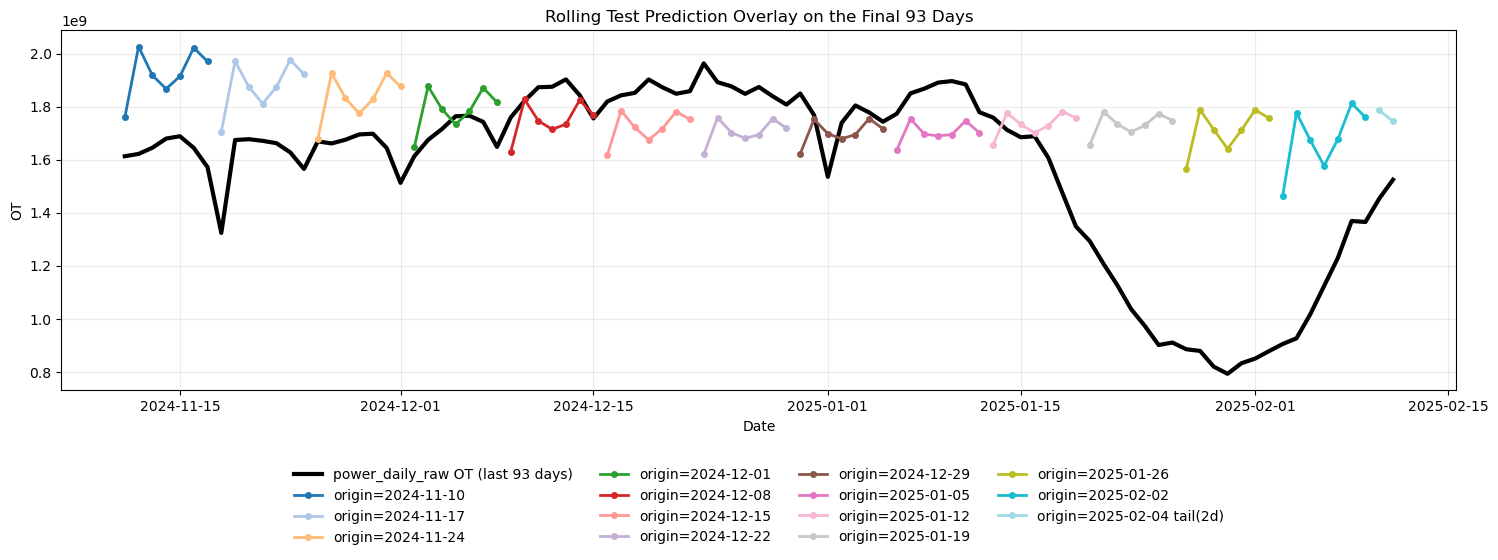

Saved plot to: F:\bishe\Baseline\artifacts\rolling_test_overlay.png


In [32]:
def plot_overlay(
    power_raw: pd.DataFrame,
    selected_windows: pd.DataFrame,
    output_path: Path,
) -> tuple[plt.Figure, plt.Axes]:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(
        power_raw["date"],
        power_raw["OT"],
        color="black",
        linewidth=3,
        label="power_daily_raw OT (last 93 days)",
    )

    group_labels = selected_windows["group_label"].drop_duplicates().tolist()
    colors = plt.cm.tab20(np.linspace(0, 1, len(group_labels)))

    for color, group_label in zip(colors, group_labels):
        group_df = (
            selected_windows.loc[selected_windows["group_label"] == group_label]
            .sort_values("target_date")
            .reset_index(drop=True)
        )
        ax.plot(
            group_df["target_date"],
            group_df["y_pred"],
            color=color,
            linewidth=2,
            marker="o",
            markersize=4,
            label=group_label,
        )

    ax.set_title("Rolling Test Prediction Overlay on the Final 93 Days")
    ax.set_xlabel("Date")
    ax.set_ylabel("OT")
    ax.grid(True, alpha=0.25)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=4,
        frameon=False,
    )
    fig.subplots_adjust(bottom=0.28)
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig, ax


fig, ax = plot_overlay(power_tail_df, selected_windows_df, OUTPUT_PATH)
assert OUTPUT_PATH.exists(), f"Expected output plot at {OUTPUT_PATH}"
print(f"Saved plot to: {OUTPUT_PATH.resolve()}")
